# Trabajo Semanal 3 <img src="fig/logo_utn_encabezado.png" width="250" align="right"/>
## por Julián Galeano Pinazo
### Teoría de los Circuitos II - Docentes: Mariano Llamedo Soria y David Moharos


#### Dada la siguiente plantilla de diseño:

<img src="fig/plantilla.png" style="float: left; margin-right: 10px;" width="400"/>

\
\
\
\
$\begin{cases}
\alpha_{max} = 0.5 \text{ dB} \\
\alpha_{min} = 30 \text{ dB} \\
F_p = 40 \text{ kHz} \\
F_s = 10 \text{ kHz}
\end{cases}$

#### 1. Obtenga la transferencia mediante aproximación de Chebyshev del filtro requerido.

Primero, obtenemos el prototipo pasa-bajo a partir del filtro objetivo:

$$
\begin{cases}
\alpha_{max} = 0.5 \text{ dB} \\
\alpha_{min} = 30 \text{ dB} \\
F_p = 40 \text{ kHz} \Rightarrow W_p = 1 \\
F_s = 10 \text{ kHz} \Rightarrow W_s = \frac{1}{4}
\end{cases}
\hspace{1cm} \Rightarrow \hspace{1cm}
\begin{cases}
\alpha_{max} = 0.5 \text{ dB} \\
\alpha_{min} = 30 \text{ dB} \\
W_p = 1 \\
W_s = 4
\end{cases}
$$

Obtenemos $\varepsilon^2$ y $n$:

$$
\varepsilon^2 = 10^{\frac{\alpha_{max}}{10}} - 1 \cong 0.122
$$

Para $n$ iteramos sobre:

$$
\alpha_s = 10 \log\left(1 + \varepsilon^2 \cosh^2\left(n \cdot \cosh^{-1}(W_s)\right)\right) > \alpha_{min}
$$

$$
\begin{array}{c|c}
n & \alpha_{min} \text{ [dB]} \\
\hline
2 & 29.73 \\
3 & 38.61 \\
\end{array}
\hspace{1cm} \Rightarrow \hspace{1cm}
\begin{cases}
\varepsilon^2 = 0.122 \\
n = 3
\end{cases}
$$

A continuación se verifica el parámetro $\varepsilon$ y el orden $n$ calculados utilizando numpy:

In [1]:
import numpy as np

amax=0.5
ws=4

print("Mediante aproximación de Chevyshev:")
epsq = 10**(amax/10)-1 
for n in np.arange(2,4):
    amin=10*np.log10(1+epsq*np.cosh(n*np.acosh(ws))**2)
    print(f"Atenuación para orden {n}: {amin} dB")

print("\nMediante aproximación Butterworth:")
amin_but=10*np.log10(1+epsq*ws**(2*3))
print(f"Atenuación para orden 3: {amin_but} dB")

Mediante aproximación de Chevyshev:
Atenuación para orden 2: 20.7283689995691 dB
Atenuación para orden 3: 38.612649509222685 dB

Mediante aproximación Butterworth:
Atenuación para orden 3: 26.996535570765463 dB


También se verificó la atenuación en banda de rechazo que se hubiera logrado con una aproximación de maxima planicidad del mismo orden y $\varepsilon$, la cual no cumple con los requerimientos de la plantilla. La ventaja mas grande de las aproximaciones de Chevyshev es que transicionan de la banda de paso a la banda de rechazo de forma mas rápida que las de máxima planicidad.

Continuando con la obtención de la transferencia, ahora obtenemos la expresión polinomica de $T^2(\omega)$:

$$
T^2(\omega) = \frac{1}{1 + \varepsilon^2 \, C_3(\omega)^2}
= \frac{1}{1 + \varepsilon^2 \left(2\omega(2\omega - 1) - \omega\right)^2}
= \frac{1}{1 + \varepsilon^2 \left(4\omega^3 - 3\omega\right)^2}
$$

$$
= \frac{1}{1 + \varepsilon^2 \left(16\omega^6 - 24\omega^4 + 9\omega^2\right)}
= \frac{\dfrac{1}{16\varepsilon^2}}{\omega^6 - \dfrac{3}{2}\omega^4 + \dfrac{9}{16}\omega^2 + \dfrac{1}{16\varepsilon^2}}
$$

con  $T^2(\omega)$, realizamos el cambio de variables $\omega=\dfrac{s}{j}$ y factorizamos en $T(s)T(-s)$:

$$
\Rightarrow T^2(s)\Big|_{\omega = \frac{s}{j}} = T(s)\,T(-s)
= \frac{\dfrac{1}{16\varepsilon^2}}{(-1)^3 s^6 - \dfrac{3}{2}(-1)^2 s^4 + \dfrac{9}{16}(-1)^1s^2 + \dfrac{1}{16\varepsilon^2}}
$$

$$
T^2(s)= \frac{\dfrac{1}{16\varepsilon^2}}{-s^6 - \dfrac{3}{2}s^4 - \dfrac{9}{16}s^2 + \dfrac{1}{16\varepsilon^2}}
= \frac{d}{s^3 + as^2 + bs + c} \cdot \frac{d}{-s^3 + as^2 - bs + c} = T(s)T(-s)
$$

$$
\Rightarrow c = d = \frac{1}{4\varepsilon} = 0.716
$$

$$
\left(s^3 + as^2 + bs + c\right)\left(-s^3 + as^2 - bs + c\right) = -s^6 - \frac{3}{2}s^4 - \frac{9}{16}s^2 + c^2
$$

$$
-s^6 + as^5 - bs^4 + cs^3 - as^5 + a^2s^4 - abs^3 + acs^2 - bs^4 + abs^3 - b^2s^2 + bcs - cs^3 + acs^2 - bcs + c^2 \\
= -s^6 - \frac{3}{2}s^4 - \frac{9}{16}s^2 + c^2
$$

$$
s^6 + (2b - a^2)s^4 + (b^2 - 2ac)s^2 - c^2 = s^6 + \frac{3}{2}s^4 + \frac{9}{16}s^2 - c^2
$$

$$
\Rightarrow \frac{9}{16} = b^2 - 2ac
\Rightarrow \frac{9}{16} + 2ac = b^2
\Rightarrow b = \sqrt{\frac{9\varepsilon + 8ac}{16\varepsilon^2}}
\Rightarrow b \approx 1.536
$$

$$
2b - a^2 = \frac{3}{2}
\Rightarrow 2\sqrt{\frac{9\varepsilon + 8ac}{16\varepsilon^2}} - a^2 = \frac{3}{2}
\Rightarrow a \approx 1.254
$$

Con los coeficientes de $T(s)T(-s)$ hallados, nos quedamos con $T(s)$ y factorizamos el polinomio en raíces:

$$
\Rightarrow T(s) = \frac{0.716}{s^3 + 1.254s^2 + 1.536s + 0.716} = \frac{0.716}{(s + P_1)(s + P_2)(s + P_2^*)}
$$

$$
\Rightarrow P_1 = 0.627, \quad
P_2 =
\begin{cases}
0.314 + j1.022 \\
0.314 - j1.022
\end{cases}
$$

Hallados los polos, planteamos las secciones de segundo orden $SOS_n$:

$$
T_{SOS_1} = \frac{0.627}{s + 0.627} \text{ (Sección de primer orden)}
$$

$$
T_{SOS_2}(s) = \frac{?}{(s + 0.314 + j1.022)(s + 0.314 - j1.022)}
= \frac{?}{s^2 + 0.628s + 1.044 + 0.0386}
= \frac{1.143}{s^2 + 0.628s + 1.143}
$$

$$
0.627 \cdot 1.143 \approx 0.716 = \frac{1}{4\varepsilon_0} \checkmark
$$

Finalmente, aplicamos la Transformación pasa-alto $\$ = \dfrac{1}{s}$ sobre las $SOS$:

$$
T_{SOS_1}(s) = \frac{0.627}{\dfrac{1}{s} + 0.627}
= \frac{s \cdot 0.627}{s \cdot 0.627 + 1}
= \frac{s}{s + 1.595}
\Rightarrow SOS_1:
\begin{cases}
\omega_0 = 1.595
\end{cases}
$$

$$
T_{SOS_2}(s) = \frac{1.143}{\dfrac{1}{s^2} + \dfrac{1}{s} \cdot 0.628 + 1.143}
= \frac{s^2 \cdot 1.143}{s^2 \cdot 1.143 + s \cdot 0.628 + 1}
= \frac{s^2}{s^2 + 0.5495s + 0.875}
$$

$$
\Rightarrow SOS_2:
\begin{cases}
\omega_0^2 = 0.875 \Rightarrow \omega_0 = 0.935 \\
\dfrac{\omega_0}{Q} = 0.549 \Rightarrow Q = 1.704
\end{cases}
$$

A continuación se verifica mediante la función _scipy.signal.chev1ap_, la cual genera una aproximación de Chevyshev del orden y ripple deseado de forma numérica, que se llegó al resultado correcto:

In [2]:
import numpy as np
import scipy.signal as sp
from pytc2.sistemas_lineales import bodePlot, pzmap, tf2sos_analog, pretty_print_SOS, pretty_print_lti

ripple = 0.5

z,p,k = sp.cheb1ap(3, ripple)
num,den = sp.zpk2tf(z,p,k)
T_lp = sp.TransferFunction(num,den)

print("Transferencia del prototipo pasa-bajos:")
pretty_print_lti(T_lp)

num_hp,den_hp = sp.lp2hp(num,den)quedamos
T_hp = sp.TransferFunction(num_hp,den_hp)

SOS_hp = tf2sos_analog(num_hp, den_hp)
print("\nTransferencia del filtro objetivo en SOS:")
pretty_print_SOS(SOS_hp)

Transferencia del prototipo pasa-bajos:


<IPython.core.display.Math object>


Transferencia del filtro objetivo en SOS:


<IPython.core.display.Math object>

Las ganancias que se ven en las $SOS$ multiplicadas son igual a uno, por lo que no tienen ningun efecto. Aparecen, proablemente, como producto del calculo numerico y se pueden ignorar.

#### 2. Obtenga la respuesta en frecuencia de forma cualitativa. Compare con la del filtro pasa-bajo

<img src="fig/respuesta_freq.jpeg"  width="800"/>

Para comparar los diagramas de polos y ceros, se usará python:

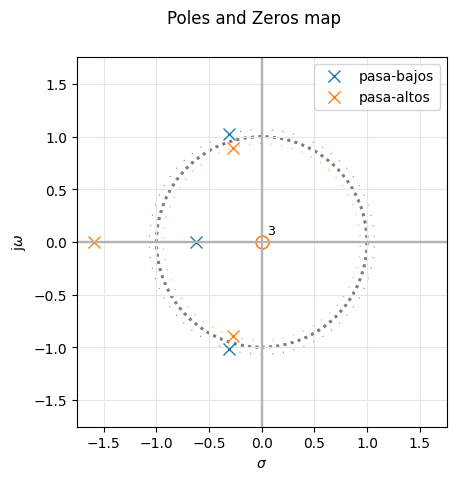

In [3]:
from matplotlib import pyplot as plt

pzmap(T_lp, filter_description="pasa-bajos", fig_id='1')
pzmap(T_hp, filter_description="pasa-altos", fig_id='1')

plt.plot(1)

Se puede ver como, ademas de los 3 ceros en el origen de la transferencia pasa-altos, los polos de cada transferencia se encuentran invertidos respecto a la circunferencia de radio $\omega_0 = 1$ respecto a los polos de la otra, que es lo que se hace al aplicar la transformación $\$=\dfrac{1}{s}$.

#### 3. Implementar el circuito normalizado con estructuras pasivas utilizando dispositivos activos para separar secciones.

Primero se eligen las normas de impedancia, con el siguiente criterio:
1. En la primera sección, solo se debe fijar $\omega_0$, por lo que el grado de libertad del capacitor alcanza
2. En la segunda sección, se tienen dos parametros a fijar $\omega_0$ y $Q$, y se puede parametrizar ambos en funcion de $L$ y $C$

$$
\Rightarrow \Omega_Z = R_1 = R_2 = R \wedge \Omega_\omega = 1
$$

La primera sección es simple, $\omega_{01} = \dfrac{1}{R_1 C_1} \Rightarrow C_1 = \dfrac{1}{\omega_{01}}$.

Para la segunda se tiene que armar un sistema de ecuaciones donde $Q_2$ y $\omega_{02}$ esten en funcion de $L_2$ y $C_2$:

$$
\begin{cases}
\omega_{02} = \dfrac{1}{\sqrt{L_2 C_2}} \\
Q_2 =\sqrt{\dfrac{L_2}{C_2}}\dfrac{1}{R_2}
\end{cases}
\hspace{1cm} \Rightarrow \hspace{1cm}
\begin{cases}
\dfrac{Q_2}{\omega_{02}} = \sqrt{\dfrac{L_2}{C_2}}\sqrt{L_2 C_2} \Rightarrow L_2 = \dfrac{Q_2}{\omega_{02}} \\
Q_2 \cdot \omega_{02} = \sqrt{\dfrac{L_2}{C_2}}\dfrac{1}{\sqrt{L_2 C_2}} \Rightarrow C_2 = \dfrac{1}{Q_2 \cdot \omega_{02}}
\end{cases}
$$

A continuación los resultados simulados en LTSpice:

<img src="fig/pasivos.png"  width="800"/>
<img src="fig/pasivos_cursor.png" align="right"  width="250"/>
<img src="fig/pasivos_graf.png"  width="700"/>

#### 4. Reemplace los inductores en las estructuras pasivas mediante el GIC de Antoniou, en la configuración que considere más apropiada.

La impedancia equivalente del GIC de Antoniou es:
$$ Z_{eq}=\frac{Z_1 Z_3 Z_5}{Z_2 Z_4} $$

Entonces, para $Z_1=Z_3=Z_4=Z_5=1$ y $Z_2=\dfrac{1}{sC_2}$:
$$ Z_{eq}=sC_2 \Rightarrow C_2 = L_2$$

<img src="fig/gic.png"  width="700"/>
<img src="fig/gic_cursor.png" align="right"  width="250"/>
<img src="fig/gic_graf.png"  width="700"/>

Se puede observar como la diferencia entre este filtro y el que usa unicamente componentes pasivos es despreciable.

#### 5. Reemplace la SOS pasiva del punto 3 por la estructura MFB en configuración pasa altos y realice el estudio de sensibilidad de $S^{\omega_0}_{C_1}$, $S^{Q}_{R_1}$ y $S^{Q}_{R_2}$

La transferencia del filtro Multiple-Feedback pasa-altos es:

$$ T(s) = K\frac{s^2\dfrac{G_1 G_2}{C_1 C_2}}{s^2+s\dfrac{G_2(C_1+C_2+C_3)}{C_1 C_2}+\dfrac{G_1 G_2}{C_1 C_2}}, \quad K=\frac{C_3 C_2}{G_1 G_2} $$

$$
\begin{cases}
\omega_0 = \sqrt{\dfrac{G_1 G_2}{C_1 C_2}} \\
\dfrac{\omega_0}{Q} = \dfrac{G_2(C_1+C_2+C_3)}{C_1 C_2} \Rightarrow Q = \sqrt{\dfrac{C_1 C_2 G_1}{G_2}} \dfrac{1}{C_1+C_2+C_3}
\end{cases}
$$

Entonces planteamos $C_1 = C_2 = C_3 = \frac{1}{\Omega_Z}$:

$$
\begin{cases}
\omega_0 = \sqrt{G_1 G_2} \\
Q = \dfrac{1}{3} \sqrt{\dfrac{G_1}{G_2}}
\end{cases}
\hspace{1cm} \Rightarrow \hspace{1cm}
\begin{cases}
Q \cdot \omega_0 = \dfrac{1}{3} \sqrt{\dfrac{G_1}{G_2}} \sqrt{G_1 G_2} \Rightarrow G_1 = 3Q\omega_0\\
\dfrac{Q}{\omega_0} = \dfrac{1}{3} \sqrt{\dfrac{G_1}{G_2}} \dfrac{1}{\sqrt{G_1 G_2}} \Rightarrow G_2= \dfrac{1}{3} \dfrac{\omega_0}{Q}
\end{cases}
$$

A continuación simulado en LTSpice:

<img src="fig/mfb.png"  width="800"/>
<img src="fig/mfb_cursor.png" align="right"  width="250"/>
<img src="fig/mfb_graf.png"  width="700"/>

Una vez mas, la diferencia es despreciable.

##### Estudio de sensibilidad:

La sensibilidad $S^{y}_{x}$ se define como:
$$\frac{\Delta y}{y} = \frac{\Delta x}{x} S^{y}_{x}\text{ ,}\quad S^{y}_{x} = \frac{x}{y} \frac{\partial y}{\partial x}$$

Representa que tanto afecta a un parametro $y$ las variaciones aleatorias que puede llegar a tener una variable $x$.

$$S^{\omega_0}_{C_1} = \frac{C_1}{\omega_0} \frac{\partial \omega_0}{\partial C_1}= \frac{C_1}{\sqrt{\dfrac{G_1 G_2}{C_1 C_2}}} \frac{\partial}{\partial C_1}\left[ \sqrt{\dfrac{G_1 G_2}{C_1 C_2}} \right] = \frac{C_1\sqrt{C_1 C_2}}{\sqrt{G_1 G_2}} \sqrt{\dfrac{G_1 G_2}{C_2}} \dfrac{-1}{2C_1\sqrt{C_1}}$$
$$S^{\omega_0}_{C_1} = -\frac{1}{2}$$

$$S^{Q}_{R_1} = \frac{R_1}{Q} \frac{\partial Q}{\partial R_1} =
\frac{R_1}{\sqrt{\frac{C_1 C_2 R_2}{R_1}}\frac{1}{C_1+C_2+C_3}} \frac{\partial}{\partial R_1} \left[ \sqrt{\frac{C_1 C_2 R_2}{R_1}}\frac{1}{C_1+C_2+C_3} \right] $$
$$S^{Q}_{R_1} = \frac{R_1\sqrt{R_1}}{\sqrt{C_1 C_2 R_2}\frac{1}{C_1+C_2+C_3}} \sqrt{C_1 C_2 R_2}\frac{1}{C_1+C_2+C_3} \left[ \frac{-1}{2R_1\sqrt{R_1}} \right]$$
$$ S^{Q}_{R_1} = -\frac{1}{2} $$

$$S^{Q}_{R_2} =  \frac{R_2}{Q} \frac{\partial Q}{\partial R_2} =
\frac{R_2}{\sqrt{\frac{C_1 C_2 R_2}{R_1}}\frac{1}{C_1+C_2+C_3}} \frac{\partial}{\partial R_2} \left[ \sqrt{\frac{C_1 C_2 R_2}{R_1}}\frac{1}{C_1+C_2+C_3} \right] $$
$$S^{Q}_{R_2} = \frac{\sqrt{R_2}}{\sqrt{\frac{C_1 C_2}{R_1}}\frac{1}{C_1+C_2+C_3}} \sqrt{\frac{C_1 C_2}{R_1}}\frac{1}{C_1+C_2+C_3} \left[ \frac{1}{2\sqrt{R_2}} \right]$$
$$ S^{Q}_{R_1} = \frac{1}{2} $$